In [4]:
import numpy as np 
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [5]:
df = pd.read_csv('C:\\Users\\HFCS\\OneDrive - Egyptian E-Learning University\\Attachments\\Desktop\\BNS_AIS2_S2_ML\\insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [7]:
df.drop(['region', 'children'], axis=1, inplace=True)
df.head()

,age,sex,bmi,smoker,charges
0,19,female,27.900,yes,16884.92400
1,18,male,33.770,no,1725.55230
2,28,male,33.000,no,4449.46200
3,33,male,22.705,no,21984.47061
4,32,male,28.880,no,3866.85520


In [8]:
dtypes = df.dtypes
n_uniq = df.nunique()
pd.DataFrame({"Dtype":dtypes, "Num_Uniqe":n_uniq}).T

,age,sex,bmi,smoker,charges
Dtype,int64,str,float64,str,float64
Num_Uniqe,47,2,548,2,1337


In [10]:
def chk_types(data):
    dtypes = df.dtypes
    n_uniq = df.nunique()
    
    return pd.DataFrame({"Dtype":dtypes, "Num_Uniqe":n_uniq}).T

In [11]:
def chk_types_table(data):
    return pd.DataFrame({
        "Dtype": data.dtypes,
        "Num_Unique": data.nunique()
    }).T


In [12]:
chk_types_table(df)

,age,sex,bmi,smoker,charges
Dtype,int64,str,float64,str,float64
Num_Unique,47,2,548,2,1337


In [22]:
print(list(df.columns))

['age', 'sex', 'bmi', 'smoker', 'charges']


In [23]:
cols = ['sex', 'smoker']
df[cols] = df[cols].astype('category')


In [24]:
chk_types(df)

,age,sex,bmi,smoker,charges
Dtype,int64,category,float64,category,float64
Num_Uniqe,47,2,548,2,1337


In [25]:
df.shape[0]

1338

In [26]:
null = df.isnull().sum()
ratio = (null/ df.shape[0])*100
pd.DataFrame({"Null":null, "ratio % ":ratio}).T

,age,sex,bmi,smoker,charges
Null,0.0,0.0,0.0,0.0,0.0
ratio %,0.0,0.0,0.0,0.0,0.0


In [28]:
median_1 = df['age'].median()
df['age'].fillna(median_1, inplace=True)


0       19
1       18
2       28
3       33
4       32
        ..
1333    50
1334    18
1335    18
1336    21
1337    61
Name: age, Length: 1338, dtype: int64

In [31]:
df.dropna(inplace=True)

In [32]:
null = df.isnull().sum()
ratio = (null/ df.shape[0])*100
pd.DataFrame({"Null":null, "ratio % ":ratio}).T

,age,sex,bmi,smoker,charges
Null,0.0,0.0,0.0,0.0,0.0
ratio %,0.0,0.0,0.0,0.0,0.0


In [34]:
num_cols = df.select_dtypes(include=['number']).columns

In [35]:
num_cols

Index(['age', 'bmi', 'charges'], dtype='str')

In [36]:
import matplotlib.pyplot as plt 
import seaborn as sns 


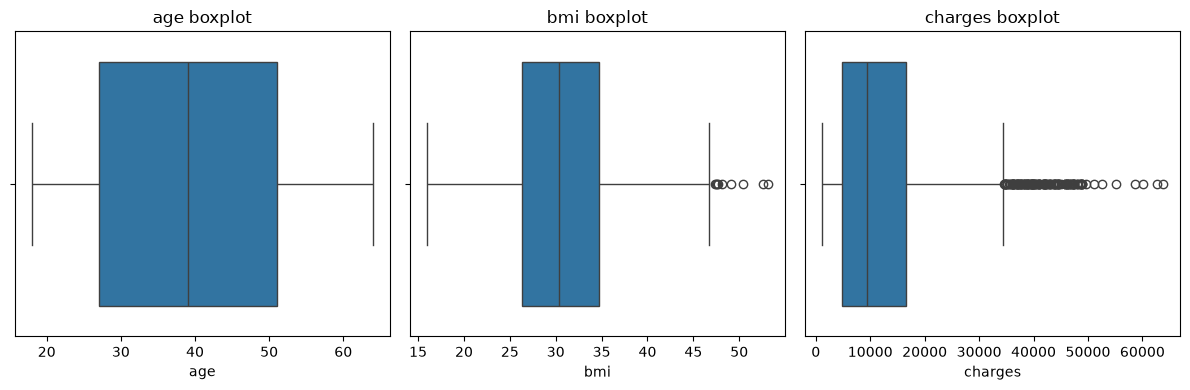

In [38]:
plt.figure(figsize=(12, 4))
for i, col in enumerate(num_cols):
    plt.subplot(1, len(num_cols), i+1)
    sns.boxplot(df[col], orient="h")
    plt.title(f"{col} boxplot")
plt.tight_layout()
plt.show()

In [39]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(.75)
    IQR = Q3 - Q1
    lower_fence = Q1 - 1.5* IQR
    upper_fence = Q3 +   1.5* IQR
    # print(lower_fence)
    lower_outliers = df[   df[col] < lower_fence    ][col].values 
    upper_outliers = df[ df[col] > upper_fence][col].values 

    df[col] = df[col].replace(lower_outliers, lower_fence)
    df[col] = df[col].replace(upper_outliers, upper_fence)



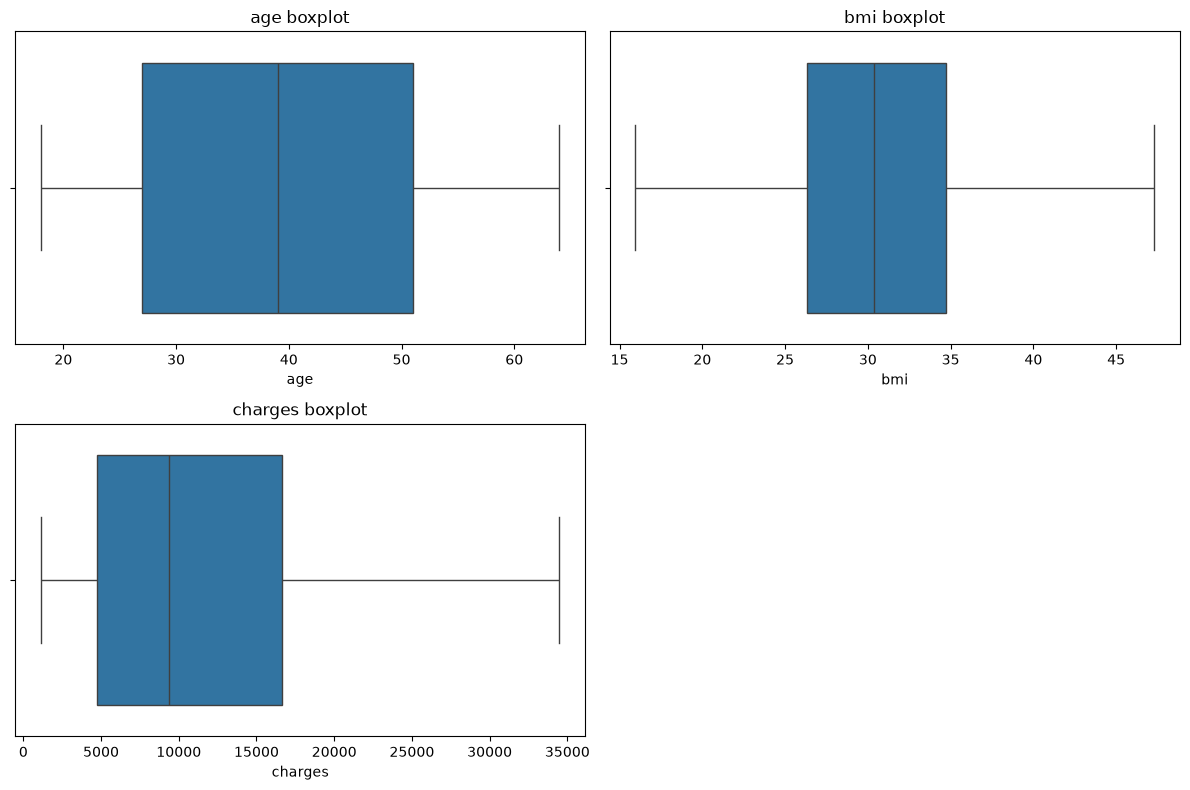

In [41]:
plt.figure(figsize=(12, 8))
for i, col in enumerate(num_cols):
    plt.subplot(2, 2, i+1)
    sns.boxplot(data=df, x=col, orient="h")
    plt.title(f"{col} boxplot")
plt.tight_layout()
plt.show()

In [43]:
unique = df['sex'].value_counts()
count = unique.values
print(unique)
print(count)

sex
male      676
female    662
Name: count, dtype: int64
[676 662]


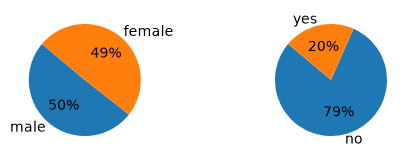

In [44]:
cat_cols = df.select_dtypes("category").columns

plt.figure(figsize=(9,4))
for i, col in enumerate(cat_cols):
    plt.subplot(2, 3 , i+1)
    unique = df[col].value_counts()
    count = unique.values
    categories =  unique.index
    plt.pie(count, labels=categories, startangle=140, autopct= '%1.1d%%')

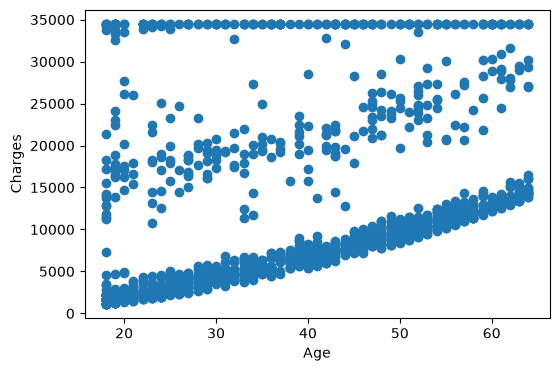

In [46]:
plt.figure(figsize=(6, 4))
plt.scatter(df['age'], df['charges'])
plt.xlabel("Age")
plt.ylabel("Charges")
plt.show()

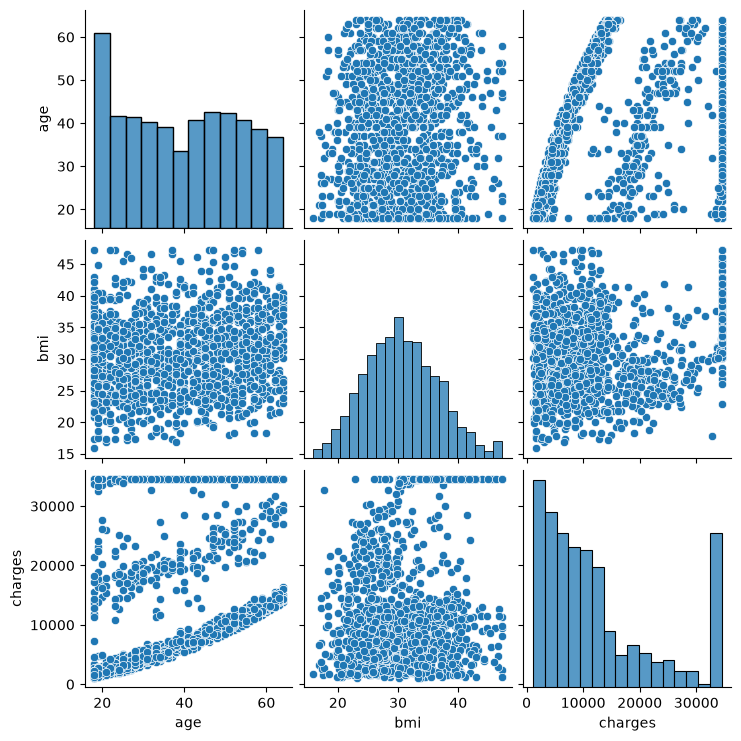

In [47]:
sns.pairplot(df)

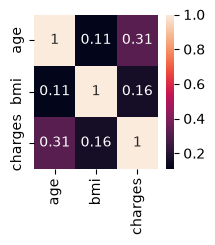

In [48]:
corr  =  df[num_cols].corr()

plt.figure(figsize=(2,2))
sns.heatmap(corr, annot=True)
plt.show()

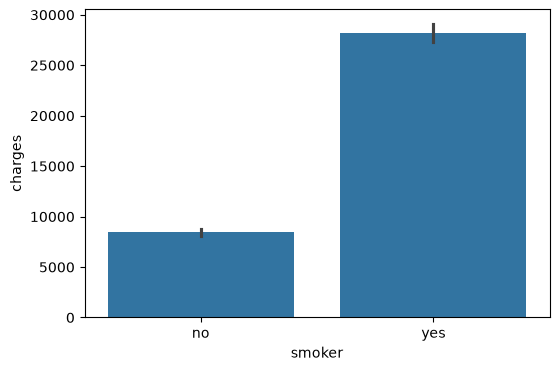

In [50]:
plt.figure(figsize=(6, 4))
sns.barplot(x="smoker", y="charges", data=df)
plt.show()

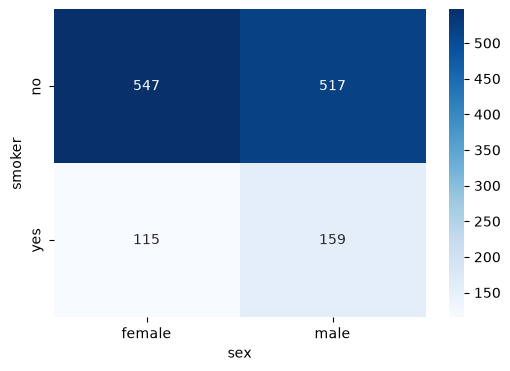

In [57]:
plt.figure(figsize=(6, 4))
agg = pd.crosstab(df["smoker"], df["sex"])
sns.heatmap(agg, annot=True, fmt="d", cmap="Blues")
plt.show()